# GMR Sweet Spot Analysis — Notebook Version

Notebook ini adalah versi `.ipynb` dari script `00.group_task_surya.py`.

Isi utama notebook:
1. Load dan preprocessing data quote-level.
2. Cleaning duplicate quote-product dan quantity 0.
3. Aggregation ke level quote.
4. Gross Margin Rate (GMR) range analysis.
5. Visualisasi win rate dan expected profit per quote.
6. Sweet spot candidate selection.
7. Export hasil analisis ke folder `output/`.

> Catatan label: `convert_to_order = 0` berarti **Success**, sedangkan `convert_to_order = 1` berarti **Fail**.


In [18]:
# ============================================================
# 1. Import libraries and notebook settings
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries loaded.")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Libraries loaded.
Output directory: C:\Users\surya\Downloads\analysis\outputs


In [19]:
# ============================================================
# 2. Set data path
# ============================================================
# The original script uses: df_preprocessed.csv
# This helper also supports: dataset/df_preprocessed.csv

possible_paths = [
    Path("../dataset/df_preprocessed.csv"),
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "df_preprocessed.csv was not found. "
        "Please place it either in the same folder as this notebook "
        "or inside the dataset/ folder."
    )

print(f"Using data file: {DATA_PATH}")


Using data file: ..\dataset\df_preprocessed.csv


In [20]:
# ============================================================
# 3. Define quote-level aggregation rule
# ============================================================

agg_dict = {
    "product": lambda x: "-".join(sorted(x)),
    "kw": "sum",
    "qty": "sum",
    "subtotal_price": "sum",
    "energy_grant_amount": "sum",
    "estimated_cost": "sum",
    "estimated_gross_profit": "sum",
    "unit_price": "mean",
    "gross_margin_rate": "mean",  # weighted version is calculated separately
    "known_num_compe": "mean",
    "competitor_count_available": "mean",
    "avg_competitor_price": "mean",
    "min_competitor_price": "min",
    "max_competitor_price": "max",
    "price_gap_avg_competitor": "mean",
    "price_gap_avg_competitor_pct": "mean",
    "is_highest_price": "mean",
    "is_compe_a": "max",
    "is_compe_b": "max",
    "is_compe_c": "max",
    "higher_than_avg_competitor": "mean",
    "is_lower_than_competitor": "mean",
    "effective_price_after_grant": "sum",
    "grant_ratio_to_subtotal": "mean",
    "convert_to_order": "first",
}

agg_dict


{'product': <function __main__.<lambda>(x)>,
 'kw': 'sum',
 'qty': 'sum',
 'subtotal_price': 'sum',
 'energy_grant_amount': 'sum',
 'estimated_cost': 'sum',
 'estimated_gross_profit': 'sum',
 'unit_price': 'mean',
 'gross_margin_rate': 'mean',
 'known_num_compe': 'mean',
 'competitor_count_available': 'mean',
 'avg_competitor_price': 'mean',
 'min_competitor_price': 'min',
 'max_competitor_price': 'max',
 'price_gap_avg_competitor': 'mean',
 'price_gap_avg_competitor_pct': 'mean',
 'is_highest_price': 'mean',
 'is_compe_a': 'max',
 'is_compe_b': 'max',
 'is_compe_c': 'max',
 'higher_than_avg_competitor': 'mean',
 'is_lower_than_competitor': 'mean',
 'effective_price_after_grant': 'sum',
 'grant_ratio_to_subtotal': 'mean',
 'convert_to_order': 'first'}

In [21]:
# ============================================================
# 4. Load preprocessed data
# ============================================================

df_raw = pd.read_csv(DATA_PATH)

# Keep compatibility with older column name from previous preprocessing.
df_raw = df_raw.rename(columns={"Success": "convert_to_order"})

print("Raw dataset shape:", df_raw.shape)
df_raw.head()


Raw dataset shape: (4991, 35)


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,price_order,is_highest_price,is_compe_a,is_compe_b,is_compe_c,known_num_compe,avg_compe_price,max_compe_price,min_compe_price,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,price_gap_min_competitor,price_gap_min_competitor_pct,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,estimated_cost,estimated_gross_profit
0,Q-00114,W,11.0,136000.0,1,136000.0,0.0712,0,66000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,70000.0,0.485294,126316.800,9683.200
1,Q-00119,H1,37.0,290000.0,2,580000.0,0.3079,0,222000,360000.0,NaN,NaN,1,1,True,False,False,1,360000.0,360000.0,360000.0,1,360000.0,360000.0,360000.0,-70000.0,-19.444444,-70000.0,-19.444444,0.0,True,358000.0,0.382759,401418.000,178582.000
2,Q-00161,Y,150.0,2379000.0,1,2379000.0,0.4224,1,720000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1659000.0,0.302648,1374110.400,1004889.600
3,Q-00167,O1,75.0,775970.0,1,775970.0,0.4117,0,375000,760000.0,900000.0,NaN,1,1,True,True,False,2,830000.0,900000.0,760000.0,2,830000.0,760000.0,900000.0,-54030.0,-6.509639,15970.0,2.101316,0.0,True,400970.0,0.483266,456503.151,319466.849
4,Q-00214,I1,22.0,300000.0,1,300000.0,0.6787,0,132000,240000.0,NaN,NaN,1,1,True,False,False,1,240000.0,240000.0,240000.0,1,240000.0,240000.0,240000.0,60000.0,25.000000,60000.0,25.000000,1.0,False,168000.0,0.440000,96390.000,203610.000


In [22]:
# ============================================================
# 5. Clean duplicate quote_id + product rows
# ============================================================
# Original intention:
# If the same quote_id and product appear more than once, keep the row
# with the highest subtotal_price as the final quoted version.

cleaned_duplicate_data = df_raw.copy()

duplicate_pairs = (
    df_raw
    .groupby(["quote_id", "product"])
    .size()
    .reset_index(name="row_count")
)

duplicate_pairs = duplicate_pairs[duplicate_pairs["row_count"] > 1]

for _, pair in duplicate_pairs.iterrows():
    q_id = pair["quote_id"]
    product = pair["product"]

    duplicate_data = df_raw[
        (df_raw["quote_id"] == q_id) &
        (df_raw["product"] == product)
    ]

    # Keep the row with the highest subtotal_price.
    keep_index = duplicate_data["subtotal_price"].idxmax()
    drop_index = duplicate_data.index.difference([keep_index])

    cleaned_duplicate_data = cleaned_duplicate_data.drop(index=drop_index, errors="ignore")

print("Duplicate quote-product pairs:", len(duplicate_pairs))
print("Shape after duplicate quote-product cleaning:", cleaned_duplicate_data.shape)


Duplicate quote-product pairs: 141
Shape after duplicate quote-product cleaning: (4764, 35)


In [23]:
# ============================================================
# 6. Remove system-error rows and exact duplicates
# ============================================================

# Remove rows with qty = 0 because they are treated as system errors.
data_qty_zero = cleaned_duplicate_data[cleaned_duplicate_data["qty"] == 0]

cleaned_data = (
    cleaned_duplicate_data
    .drop(index=data_qty_zero.index)
    .drop_duplicates()
    .reset_index(drop=True)
)

df_clean = cleaned_data.copy()

print("Rows with qty = 0 removed:", len(data_qty_zero))
print("Shape after cleaning:", df_clean.shape)
df_clean.head()


Rows with qty = 0 removed: 0
Shape after cleaning: (4764, 35)


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,price_order,is_highest_price,is_compe_a,is_compe_b,is_compe_c,known_num_compe,avg_compe_price,max_compe_price,min_compe_price,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,price_gap_min_competitor,price_gap_min_competitor_pct,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,estimated_cost,estimated_gross_profit
0,Q-00114,W,11.0,136000.0,1,136000.0,0.0712,0,66000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,70000.0,0.485294,126316.800,9683.200
1,Q-00119,H1,37.0,290000.0,2,580000.0,0.3079,0,222000,360000.0,NaN,NaN,1,1,True,False,False,1,360000.0,360000.0,360000.0,1,360000.0,360000.0,360000.0,-70000.0,-19.444444,-70000.0,-19.444444,0.0,True,358000.0,0.382759,401418.000,178582.000
2,Q-00161,Y,150.0,2379000.0,1,2379000.0,0.4224,1,720000,NaN,NaN,NaN,1,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1659000.0,0.302648,1374110.400,1004889.600
3,Q-00167,O1,75.0,775970.0,1,775970.0,0.4117,0,375000,760000.0,900000.0,NaN,1,1,True,True,False,2,830000.0,900000.0,760000.0,2,830000.0,760000.0,900000.0,-54030.0,-6.509639,15970.0,2.101316,0.0,True,400970.0,0.483266,456503.151,319466.849
4,Q-00214,I1,22.0,300000.0,1,300000.0,0.6787,0,132000,240000.0,NaN,NaN,1,1,True,False,False,1,240000.0,240000.0,240000.0,1,240000.0,240000.0,240000.0,60000.0,25.000000,60000.0,25.000000,1.0,False,168000.0,0.440000,96390.000,203610.000


In [24]:
# ============================================================
# 7. Keep multi-product quote data and check conversion consistency
# ============================================================

quote_counts = df_clean["quote_id"].value_counts()
multi_product_data_ids = quote_counts[quote_counts >= 2].index.to_list()

multi_product_data = (
    df_clean[df_clean["quote_id"].isin(multi_product_data_ids)]
    .reset_index(drop=True)
)

inconsistent_quote_ids = []

for q_id in multi_product_data_ids:
    success_values = multi_product_data.loc[
        multi_product_data["quote_id"] == q_id,
        "convert_to_order"
    ].values

    uniform = len(set(success_values)) == 1

    if not uniform:
        inconsistent_quote_ids.append(q_id)

print("Number of multi-product quote IDs:", len(multi_product_data_ids))
print("Number of inconsistent conversion labels:", len(inconsistent_quote_ids))

if inconsistent_quote_ids:
    print("Inconsistent quote IDs:")
    print(inconsistent_quote_ids)

multi_product_data.head()


Number of multi-product quote IDs: 117
Number of inconsistent conversion labels: 0


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,convert_to_order,energy_grant_amount,competitor_a,competitor_b,competitor_c,price_order,is_highest_price,is_compe_a,is_compe_b,is_compe_c,known_num_compe,avg_compe_price,max_compe_price,min_compe_price,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,price_gap_min_competitor,price_gap_min_competitor_pct,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,estimated_cost,estimated_gross_profit
0,Q-00525,H1,37.0,290000.0,2,580000.0,0.3983,0,222000,360000.0,NaN,NaN,1,1,True,False,False,1,360000.0,360000.0,360000.0,1,360000.0,360000.0,360000.0,-70000.0,-19.444444,-70000.0,-19.444444,0.0,True,358000.0,0.382759,348986.00,231014.00
1,Q-00525,I1,22.0,270000.0,1,270000.0,0.3983,0,132000,240000.0,NaN,NaN,1,1,True,False,False,1,240000.0,240000.0,240000.0,1,240000.0,240000.0,240000.0,30000.0,12.500000,30000.0,12.500000,1.0,False,138000.0,0.488889,162459.00,107541.00
2,Q-02428,O,75.0,659000.0,1,659000.0,0.4135,0,322500,NaN,NaN,NaN,2,1,False,False,False,0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,336500.0,0.489378,386503.50,272496.50
3,Q-02428,S,110.0,1141900.0,1,1141900.0,0.4135,0,528000,1880000.0,NaN,NaN,2,1,True,False,False,1,1880000.0,1880000.0,1880000.0,1,1880000.0,1880000.0,1880000.0,-738100.0,-39.260638,-738100.0,-39.260638,0.0,True,613900.0,0.462387,669724.35,472175.65
4,Q-03631,H1,37.0,360000.0,1,360000.0,0.3954,0,222000,360000.0,NaN,NaN,1,1,True,False,False,1,360000.0,360000.0,360000.0,1,360000.0,360000.0,360000.0,0.0,0.000000,0.0,0.000000,0.0,True,138000.0,0.616667,217656.00,142344.00


In [25]:
# ============================================================
# 8. Aggregate data to quote level
# ============================================================

quote_level = (
    multi_product_data
    .groupby("quote_id")
    .agg(agg_dict)
    .reset_index()
)

# Calculate weighted margin rate using subtotal_price as weight.
weighted_margin_source = multi_product_data.copy()
weighted_margin_source["weighted_gmr_component"] = (
    weighted_margin_source["gross_margin_rate"] *
    weighted_margin_source["subtotal_price"]
)

weighted_margin = (
    weighted_margin_source
    .groupby("quote_id")
    .agg(
        weighted_gmr_sum=("weighted_gmr_component", "sum"),
        subtotal_sum=("subtotal_price", "sum")
    )
    .reset_index()
)

weighted_margin["weighted_margin_rate"] = (
    weighted_margin["weighted_gmr_sum"] /
    weighted_margin["subtotal_sum"]
)

weighted_margin = weighted_margin[["quote_id", "weighted_margin_rate"]]

df = quote_level.merge(weighted_margin, on="quote_id", how="left")

print("Quote-level dataset shape:", df.shape)
df.head()


Quote-level dataset shape: (117, 27)


,quote_id,product,kw,qty,subtotal_price,energy_grant_amount,estimated_cost,estimated_gross_profit,unit_price,gross_margin_rate,known_num_compe,competitor_count_available,avg_competitor_price,min_competitor_price,max_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,is_highest_price,is_compe_a,is_compe_b,is_compe_c,higher_than_avg_competitor,is_lower_than_competitor,effective_price_after_grant,grant_ratio_to_subtotal,convert_to_order,weighted_margin_rate
0,Q-00525,H1-I1,59.0,3,850000.0,354000,5.114450e+05,338555.0000,280000.0,0.3983,1.0,1.0,300000.0,240000.0,360000.0,-20000.0,-3.472222,1.0,True,False,False,0.5,0.5,496000.0,0.435824,0,0.3983
1,Q-02428,O-S,185.0,2,1800900.0,850500,1.056228e+06,744672.1500,900450.0,0.4135,0.5,0.5,1880000.0,1880000.0,1880000.0,-738100.0,-39.260638,1.0,True,False,False,0.0,0.5,950400.0,0.475883,0,0.4135
2,Q-03631,H1-N1,112.0,2,1009000.0,597000,6.100414e+05,398958.6000,504500.0,0.3954,1.5,1.5,595000.0,360000.0,900000.0,-90500.0,-10.903614,1.0,True,True,False,0.0,1.0,412000.0,0.597239,0,0.3954
3,Q-05821,I1-J,44.0,2,577864.0,245520,3.707575e+05,207106.4576,288932.0,0.3584,0.5,0.5,240000.0,240000.0,240000.0,44076.0,18.365000,1.0,True,False,False,1.0,0.0,332344.0,0.425533,1,0.3584
4,Q-05850,H1-I1,59.0,2,681876.0,354000,3.631672e+05,318708.8424,340938.0,0.4674,1.0,1.0,300000.0,240000.0,360000.0,40938.0,14.562500,1.0,True,False,False,1.0,0.0,327876.0,0.511165,0,0.4674


In [26]:
# ============================================================
# 9. Prepare GMR analysis data
# ============================================================

df_gmr_analysis = df.copy()

# Keep final/highest-price quotes only.
df_gmr_analysis = df_gmr_analysis[
    df_gmr_analysis["is_highest_price"] == 1
].copy()

bins = [
    -np.inf,
    -0.20,
    -0.10,
    0,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    np.inf
]

labels = [
    "< -20%",
    "-20% to -10%",
    "-10% to 0%",
    "0% to 10%",
    "10% to 20%",
    "20% to 30%",
    "30% to 40%",
    "40% to 50%",
    "50% to 60%",
    "> 60%"
]

df_gmr_analysis["gmr_range"] = pd.cut(
    df_gmr_analysis["gross_margin_rate"],
    bins=bins,
    labels=labels,
    right=False
)

df_gmr_analysis["success"] = (
    df_gmr_analysis["convert_to_order"] == 0
).astype(int)

print("GMR analysis dataset shape:", df_gmr_analysis.shape)
df_gmr_analysis[[
    "quote_id",
    "product",
    "gross_margin_rate",
    "gmr_range",
    "estimated_gross_profit",
    "convert_to_order",
    "success"
]].head()


GMR analysis dataset shape: (117, 29)


,quote_id,product,gross_margin_rate,gmr_range,estimated_gross_profit,convert_to_order,success
0,Q-00525,H1-I1,0.3983,30% to 40%,338555.0000,0,1
1,Q-02428,O-S,0.4135,40% to 50%,744672.1500,0,1
2,Q-03631,H1-N1,0.3954,30% to 40%,398958.6000,0,1
3,Q-05821,I1-J,0.3584,30% to 40%,207106.4576,1,0
4,Q-05850,H1-I1,0.4674,40% to 50%,318708.8424,0,1


In [27]:
# ============================================================
# 10. Create GMR sweet spot summary
# ============================================================

gmr_sweet_spot = (
    df_gmr_analysis
    .groupby("gmr_range", observed=True)
    .agg(
        total_quotes=("quote_id", "count"),
        win_rate=("success", "mean"),
        avg_gmr=("gross_margin_rate", "mean"),
        avg_gross_profit=("estimated_gross_profit", "mean"),
        median_gross_profit=("estimated_gross_profit", "median"),
        total_potential_profit=("estimated_gross_profit", "sum")
    )
    .reset_index()
)

gmr_sweet_spot["expected_profit_per_quote"] = (
    gmr_sweet_spot["win_rate"] *
    gmr_sweet_spot["avg_gross_profit"]
)

gmr_sweet_spot["win_rate_pct"] = gmr_sweet_spot["win_rate"] * 100

gmr_sweet_spot


,gmr_range,total_quotes,win_rate,avg_gmr,avg_gross_profit,median_gross_profit,total_potential_profit,expected_profit_per_quote,win_rate_pct
0,-10% to 0%,1,1.000000,-0.073300,-2.177214e+05,-2.177214e+05,-2.177214e+05,-217721.377400,100.000000
1,0% to 10%,6,0.666667,0.062217,4.510300e+04,3.064358e+04,2.706180e+05,30068.668917,66.666667
2,10% to 20%,6,0.833333,0.146783,5.673814e+05,4.643436e+05,3.404288e+06,472817.833309,83.333333
3,20% to 30%,16,0.500000,0.257956,6.625483e+05,2.508778e+05,1.060077e+07,331274.149588,50.000000
4,30% to 40%,29,0.517241,0.357772,6.150821e+05,3.978838e+05,1.783738e+07,318145.905511,51.724138
5,40% to 50%,37,0.270270,0.439686,5.338888e+05,2.896740e+05,1.975388e+07,144294.258843,27.027027
6,50% to 60%,10,0.300000,0.551650,6.125952e+05,5.212017e+05,6.125952e+06,183778.551405,30.000000
7,> 60%,12,0.000000,0.639308,2.392653e+06,1.742859e+06,2.871184e+07,0.000000,0.000000


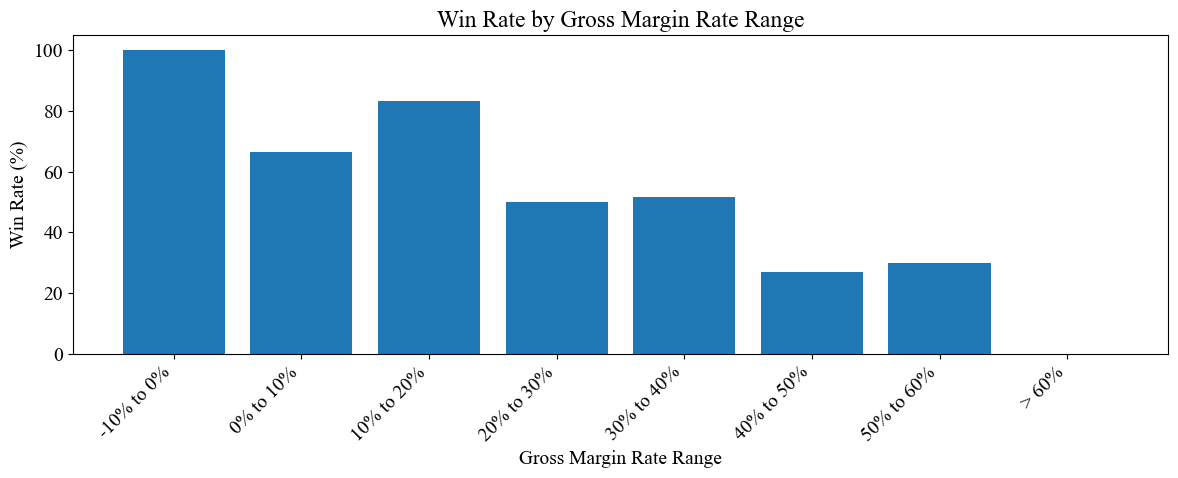

In [28]:
# ============================================================
# 11. Visualization: Win Rate by GMR range
# ============================================================

plot_df = gmr_sweet_spot.copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    plot_df["gmr_range"].astype(str),
    plot_df["win_rate_pct"]
)

ax.set_xlabel("Gross Margin Rate Range")
ax.set_ylabel("Win Rate (%)")
ax.set_title("Win Rate by Gross Margin Rate Range")

ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "win_rate_by_gmr_range.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


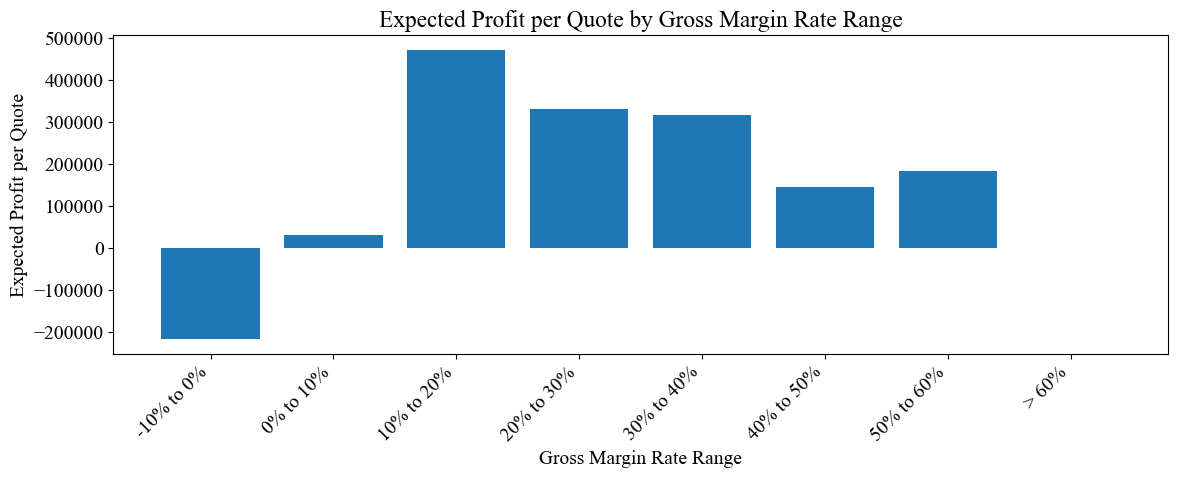

In [29]:
# ============================================================
# 12. Visualization: Expected Profit per Quote by GMR range
# ============================================================

plot_df = gmr_sweet_spot.copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    plot_df["gmr_range"].astype(str),
    plot_df["expected_profit_per_quote"]
)

ax.set_xlabel("Gross Margin Rate Range")
ax.set_ylabel("Expected Profit per Quote")
ax.set_title("Expected Profit per Quote by Gross Margin Rate Range")

ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "expected_profit_per_quote_by_gmr_range.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [30]:
# ============================================================
# 13. Display clean GMR sweet spot table
# ============================================================

gmr_sweet_spot_display = gmr_sweet_spot.copy()

gmr_sweet_spot_display["win_rate_pct"] = (
    gmr_sweet_spot_display["win_rate"] * 100
).round(2)

gmr_sweet_spot_display["avg_gmr_pct"] = (
    gmr_sweet_spot_display["avg_gmr"] * 100
).round(2)

gmr_sweet_spot_display["avg_gross_profit"] = (
    gmr_sweet_spot_display["avg_gross_profit"].round(2)
)

gmr_sweet_spot_display["expected_profit_per_quote"] = (
    gmr_sweet_spot_display["expected_profit_per_quote"].round(2)
)

gmr_sweet_spot_display = gmr_sweet_spot_display[
    [
        "gmr_range",
        "total_quotes",
        "win_rate_pct",
        "avg_gmr_pct",
        "avg_gross_profit",
        "expected_profit_per_quote"
    ]
]

gmr_sweet_spot_display


,gmr_range,total_quotes,win_rate_pct,avg_gmr_pct,avg_gross_profit,expected_profit_per_quote
0,-10% to 0%,1,100.00,-7.33,-217721.38,-217721.38
1,0% to 10%,6,66.67,6.22,45103.00,30068.67
2,10% to 20%,6,83.33,14.68,567381.40,472817.83
3,20% to 30%,16,50.00,25.80,662548.30,331274.15
4,30% to 40%,29,51.72,35.78,615082.08,318145.91
5,40% to 50%,37,27.03,43.97,533888.76,144294.26
6,50% to 60%,10,30.00,55.17,612595.17,183778.55
7,> 60%,12,0.00,63.93,2392652.93,0.00


In [31]:
# ============================================================
# 14. Select sweet spot candidates
# ============================================================
# These thresholds can be adjusted if needed.

min_quotes = 10
min_win_rate = 0.30

sweet_spot_candidates = gmr_sweet_spot[
    (gmr_sweet_spot["total_quotes"] >= min_quotes) &
    (gmr_sweet_spot["win_rate"] >= min_win_rate) &
    (gmr_sweet_spot["expected_profit_per_quote"] > 0)
].copy()

sweet_spot_candidates = sweet_spot_candidates.sort_values(
    by="expected_profit_per_quote",
    ascending=False
)

sweet_spot_candidates


,gmr_range,total_quotes,win_rate,avg_gmr,avg_gross_profit,median_gross_profit,total_potential_profit,expected_profit_per_quote,win_rate_pct
3,20% to 30%,16,0.500000,0.257956,662548.299176,250877.79981,1.060077e+07,331274.149588,50.000000
4,30% to 40%,29,0.517241,0.357772,615082.083988,397883.81952,1.783738e+07,318145.905511,51.724138
6,50% to 60%,10,0.300000,0.551650,612595.171350,521201.67600,6.125952e+06,183778.551405,30.000000


In [32]:
# ============================================================
# 15. Export output tables
# ============================================================

output_excel = OUTPUT_DIR / "gmr_sweet_spot_analysis.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Quote_Level_Data", index=False)
    df_gmr_analysis.to_excel(writer, sheet_name="GMR_Analysis_Data", index=False)
    gmr_sweet_spot.to_excel(writer, sheet_name="GMR_Sweet_Spot", index=False)
    gmr_sweet_spot_display.to_excel(writer, sheet_name="GMR_Sweet_Spot_Display", index=False)
    sweet_spot_candidates.to_excel(writer, sheet_name="Sweet_Spot_Candidates", index=False)

print(f"Output saved as: {output_excel}")
print("Figures saved to:")
print(OUTPUT_DIR / "win_rate_by_gmr_range.png")
print(OUTPUT_DIR / "expected_profit_per_quote_by_gmr_range.png")


Output saved as: ..\outputs\gmr_sweet_spot_analysis.xlsx
Figures saved to:
..\outputs\win_rate_by_gmr_range.png
..\outputs\expected_profit_per_quote_by_gmr_range.png
